# Notebook 16 — Random Forest y Gradient Boosting

En este notebook estudiaremos dos familias fundamentales de métodos de ensamble basados en árboles:

- **Random Forest**, construido mediante bagging;
- **Gradient Boosting**, construido de forma secuencial.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- explicar la diferencia entre bagging y boosting;
- comparar un árbol individual contra Random Forest;
- interpretar el papel del bootstrap y de `max_features`;
- analizar el efecto del número de árboles;
- utilizar el error Out-of-Bag;
- estudiar la importancia de variables;
- comprender cómo Gradient Boosting corrige errores secuencialmente;
- interpretar `learning_rate` y `n_estimators`;
- analizar overfitting en boosting;
- comparar desempeño, estabilidad y tiempo de ambos métodos;
- reconocer cuándo conviene utilizar cada enfoque.

Usaremos datos sintéticos de regresión generados con `scikit-learn`.

## 1. Importación de librerías

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42

pd.options.display.float_format = "{:,.4f}".format


## 2. Generación del dataset

Crearemos un problema de regresión con:

- 1,500 observaciones;
- 12 variables;
- 7 variables informativas;
- ruido moderado.

Después agregaremos una interacción no lineal para que los modelos basados en árboles tengan una ventaja frente a una especificación lineal simple.

In [2]:
X, y, true_coefficients = make_regression(
    n_samples=1_500,
    n_features=12,
    n_informative=7,
    noise=18,
    coef=True,
    random_state=RANDOM_STATE,
)

y = (
    y
    + 35 * np.sin(X[:, 0])
    + 20 * X[:, 1] * X[:, 2]
)

feature_names = [
    f"x_{index}"
    for index in range(1, X.shape[1] + 1)
]

X = pd.DataFrame(
    X,
    columns=feature_names,
)

y = pd.Series(
    y,
    name="y",
)

print(X.shape)
X.head()


(1500, 12)


,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,x_11,x_12
0,0.6041,0.0911,-1.3263,-0.4100,0.6823,0.0539,0.1077,0.5574,-0.0708,0.6322,0.9466,0.9982
1,-0.6814,1.3739,0.2329,0.9678,-1.3401,-1.2445,-0.8524,-0.6080,0.9938,-1.0145,0.4322,0.4754
2,1.0522,0.4000,1.6656,0.0974,-1.8750,-0.7722,2.2888,-0.3755,-0.2269,0.6995,1.1800,-1.7632
3,1.4196,1.0075,-0.6475,-0.6004,-0.6494,-0.3583,-0.6846,0.7442,-1.8665,-0.1812,1.3213,0.7906
4,1.4413,0.0102,-1.2478,-1.4359,-0.4400,-0.2526,-0.9815,1.6324,1.1632,-1.4301,0.1307,0.4621


## 3. Split de entrenamiento y prueba

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")


Train: (1125, 12)
Test: (375, 12)


In [4]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R²": r2_score(y_true, y_pred),
    }


# Parte I. Árbol individual como referencia

## 4. Modelo base

Un árbol profundo suele tener bajo sesgo y alta varianza, por lo que puede sobreajustar con facilidad.

In [5]:
single_tree = DecisionTreeRegressor(
    random_state=RANDOM_STATE,
)

single_tree.fit(X_train, y_train)

tree_train_pred = single_tree.predict(X_train)
tree_test_pred = single_tree.predict(X_test)

tree_results = pd.DataFrame({
    "Conjunto": ["Train", "Test"],
    "MAE": [
        mean_absolute_error(y_train, tree_train_pred),
        mean_absolute_error(y_test, tree_test_pred),
    ],
    "RMSE": [
        mean_squared_error(y_train, tree_train_pred) ** 0.5,
        mean_squared_error(y_test, tree_test_pred) ** 0.5,
    ],
    "R²": [
        r2_score(y_train, tree_train_pred),
        r2_score(y_test, tree_test_pred),
    ],
})

tree_results


,Conjunto,MAE,RMSE,R²
0,Train,0.0000,0.0000,1.0000
1,Test,84.7820,105.6538,0.6408


# Parte II. Random Forest

## 5. Intuición

Random Forest combina muchos árboles entrenados sobre muestras bootstrap y subconjuntos aleatorios de variables.

La predicción final es el promedio de las predicciones de los árboles.

In [6]:
random_forest = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=2,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

start_time = time.perf_counter()

random_forest.fit(X_train, y_train)

rf_training_time = time.perf_counter() - start_time

rf_train_pred = random_forest.predict(X_train)
rf_test_pred = random_forest.predict(X_test)

pd.DataFrame({
    "Conjunto": ["Train", "Test"],
    "RMSE": [
        mean_squared_error(y_train, rf_train_pred) ** 0.5,
        mean_squared_error(y_test, rf_test_pred) ** 0.5,
    ],
    "R²": [
        r2_score(y_train, rf_train_pred),
        r2_score(y_test, rf_test_pred),
    ],
})


,Conjunto,RMSE,R²
0,Train,33.5249,0.9575
1,Test,77.8717,0.8049


In [7]:
print(f"OOB R²: {random_forest.oob_score_:.4f}")
print(f"Tiempo de entrenamiento: {rf_training_time:.3f} segundos")


OOB R²: 0.8078
Tiempo de entrenamiento: 0.232 segundos


## 6. Bootstrap y Out-of-Bag

Cada árbol se entrena con una muestra bootstrap.

Las observaciones que quedan fuera de esa muestra pueden utilizarse para obtener una estimación OOB del desempeño.

## 7. Efecto del número de árboles

In [8]:
n_estimators_values = [10, 25, 50, 100, 200, 400, 700]
rf_size_rows = []

for n_estimators in n_estimators_values:
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_features="sqrt",
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

    start = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - start

    rf_size_rows.append({
        "Número de árboles": n_estimators,
        "RMSE train": mean_squared_error(
            y_train,
            model.predict(X_train),
        ) ** 0.5,
        "RMSE test": mean_squared_error(
            y_test,
            model.predict(X_test),
        ) ** 0.5,
        "Tiempo": elapsed,
    })

rf_size_table = pd.DataFrame(rf_size_rows)
rf_size_table


,Número de árboles,RMSE train,RMSE test,Tiempo
0,10,41.6233,85.9970,0.0168
1,25,38.3567,83.3825,0.0383
2,50,36.1847,80.3080,0.0348
3,100,34.8186,78.7312,0.0647
4,200,34.0012,78.0696,0.1114
5,400,33.5074,77.8667,0.2093
6,700,33.3815,77.4316,0.3814


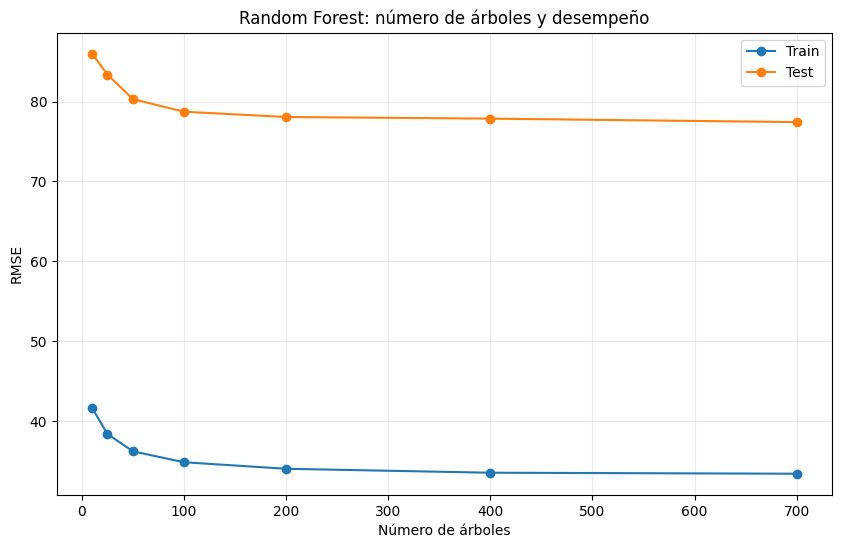

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(
    rf_size_table["Número de árboles"],
    rf_size_table["RMSE train"],
    marker="o",
    label="Train",
)
plt.plot(
    rf_size_table["Número de árboles"],
    rf_size_table["RMSE test"],
    marker="o",
    label="Test",
)
plt.xlabel("Número de árboles")
plt.ylabel("RMSE")
plt.title("Random Forest: número de árboles y desempeño")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 8. Efecto de `max_features`

In [10]:
max_feature_values = [1.0, "sqrt", "log2", 0.5]
max_feature_rows = []

for max_features in max_feature_values:
    model = RandomForestRegressor(
        n_estimators=300,
        max_features=max_features,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

    model.fit(X_train, y_train)

    max_feature_rows.append({
        "max_features": str(max_features),
        "RMSE train": mean_squared_error(
            y_train,
            model.predict(X_train),
        ) ** 0.5,
        "RMSE test": mean_squared_error(
            y_test,
            model.predict(X_test),
        ) ** 0.5,
    })

pd.DataFrame(max_feature_rows)


,max_features,RMSE train,RMSE test
0,1.0,25.4301,65.6826
1,sqrt,33.5249,77.8717
2,log2,33.5249,77.8717
3,0.5,26.8283,67.2337


## 9. Importancia de variables

Random Forest ofrece una importancia basada en reducción de impureza.

In [11]:
rf_importance = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": random_forest.feature_importances_,
}).sort_values(
    "Importancia",
    ascending=False,
)

rf_importance


,Variable,Importancia
10,x_11,0.2617
4,x_5,0.2502
9,x_10,0.1247
2,x_3,0.1082
0,x_1,0.0810
8,x_9,0.0270
7,x_8,0.0264
6,x_7,0.0244
1,x_2,0.0242
11,x_12,0.0242


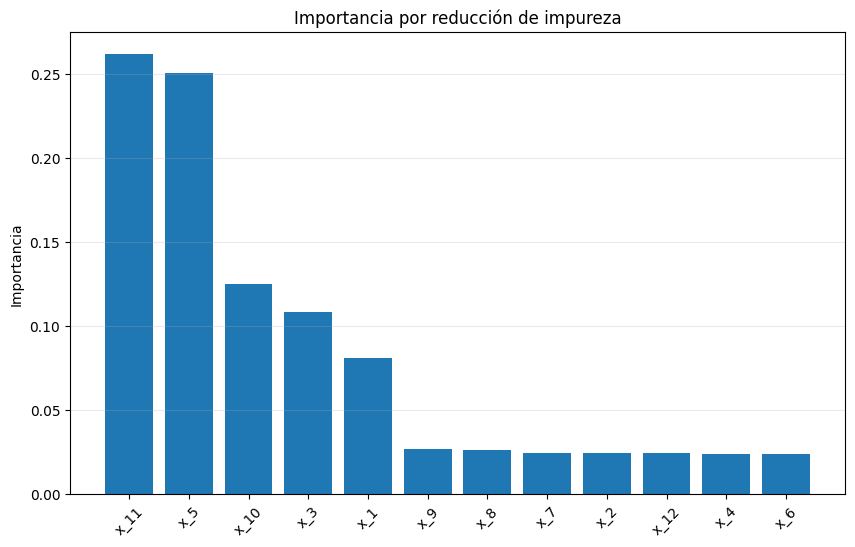

In [12]:
plt.figure(figsize=(10, 6))
plt.bar(
    rf_importance["Variable"],
    rf_importance["Importancia"],
)
plt.ylabel("Importancia")
plt.title("Importancia por reducción de impureza")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.show()


## 10. Permutation Importance

In [13]:
permutation_result = permutation_importance(
    random_forest,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=15,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_table = pd.DataFrame({
    "Variable": feature_names,
    "Importancia media": permutation_result.importances_mean,
    "Desviación": permutation_result.importances_std,
}).sort_values(
    "Importancia media",
    ascending=False,
)

permutation_table


,Variable,Importancia media,Desviación
10,x_11,54.9894,2.5008
4,x_5,54.4866,2.8986
2,x_3,27.2117,1.3806
9,x_10,25.1839,1.4633
0,x_1,16.7726,1.5853
1,x_2,0.6240,0.1666
11,x_12,0.3404,0.1826
7,x_8,0.2517,0.2951
3,x_4,-0.0467,0.1462
6,x_7,-0.1107,0.2210


# Parte III. Gradient Boosting

## 11. Intuición

Gradient Boosting construye árboles secuencialmente.

Cada nuevo árbol busca corregir los errores del ensamble anterior.

In [14]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=2,
    min_samples_leaf=5,
    loss="squared_error",
    random_state=RANDOM_STATE,
)

start_time = time.perf_counter()

gradient_boosting.fit(X_train, y_train)

gb_training_time = time.perf_counter() - start_time

gb_train_pred = gradient_boosting.predict(X_train)
gb_test_pred = gradient_boosting.predict(X_test)

pd.DataFrame({
    "Conjunto": ["Train", "Test"],
    "RMSE": [
        mean_squared_error(y_train, gb_train_pred) ** 0.5,
        mean_squared_error(y_test, gb_test_pred) ** 0.5,
    ],
    "R²": [
        r2_score(y_train, gb_train_pred),
        r2_score(y_test, gb_test_pred),
    ],
})


,Conjunto,RMSE,R²
0,Train,24.7000,0.9769
1,Test,41.4650,0.9447


In [15]:
print(f"Tiempo de entrenamiento: {gb_training_time:.3f} segundos")


Tiempo de entrenamiento: 0.510 segundos


## 12. Evolución del error

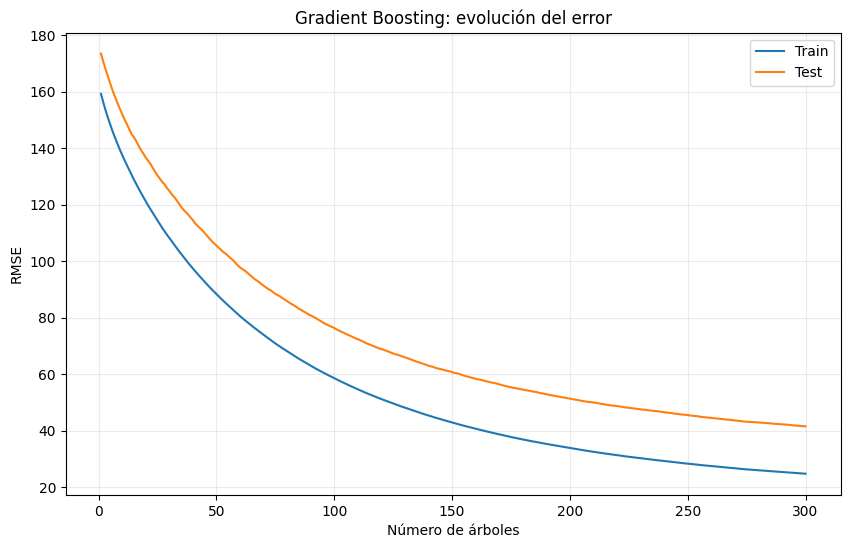

In [16]:
train_rmse_stages = []
test_rmse_stages = []

for train_stage_pred, test_stage_pred in zip(
    gradient_boosting.staged_predict(X_train),
    gradient_boosting.staged_predict(X_test),
):
    train_rmse_stages.append(
        mean_squared_error(y_train, train_stage_pred) ** 0.5
    )
    test_rmse_stages.append(
        mean_squared_error(y_test, test_stage_pred) ** 0.5
    )

stage_numbers = np.arange(1, len(train_rmse_stages) + 1)

plt.figure(figsize=(10, 6))
plt.plot(stage_numbers, train_rmse_stages, label="Train")
plt.plot(stage_numbers, test_rmse_stages, label="Test")
plt.xlabel("Número de árboles")
plt.ylabel("RMSE")
plt.title("Gradient Boosting: evolución del error")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


In [17]:
best_stage = int(np.argmin(test_rmse_stages) + 1)
print(
    "Mejor número de árboles según test "
    "(solo con fines didácticos):",
    best_stage,
)


Mejor número de árboles según test (solo con fines didácticos): 300


## 13. Efecto de `learning_rate`

In [18]:
learning_rates = [0.01, 0.03, 0.05, 0.10, 0.20]
learning_rate_rows = []

for learning_rate in learning_rates:
    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=learning_rate,
        max_depth=2,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    )

    model.fit(X_train, y_train)

    learning_rate_rows.append({
        "Learning rate": learning_rate,
        "RMSE train": mean_squared_error(
            y_train,
            model.predict(X_train),
        ) ** 0.5,
        "RMSE test": mean_squared_error(
            y_test,
            model.predict(X_test),
        ) ** 0.5,
    })

pd.DataFrame(learning_rate_rows)


,Learning rate,RMSE train,RMSE test
0,0.0100,81.1927,98.3637
1,0.0300,36.9857,54.7342
2,0.0500,24.7000,41.4650
3,0.1000,19.1734,36.1175
4,0.2000,14.5854,34.4208


## 14. Efecto de la profundidad

In [19]:
depth_values = [1, 2, 3, 4, 6]
gb_depth_rows = []

for depth in depth_values:
    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=depth,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    )

    model.fit(X_train, y_train)

    gb_depth_rows.append({
        "max_depth": depth,
        "RMSE train": mean_squared_error(
            y_train,
            model.predict(X_train),
        ) ** 0.5,
        "RMSE test": mean_squared_error(
            y_test,
            model.predict(X_test),
        ) ** 0.5,
    })

pd.DataFrame(gb_depth_rows)


,max_depth,RMSE train,RMSE test
0,1,47.8728,60.4261
1,2,24.7000,41.4650
2,3,17.3786,39.4174
3,4,12.2134,41.5103
4,6,4.6171,49.1004


## 15. Importancia de variables en Gradient Boosting

In [20]:
gb_importance = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": gradient_boosting.feature_importances_,
}).sort_values(
    "Importancia",
    ascending=False,
)

gb_importance


,Variable,Importancia
10,x_11,0.3341
4,x_5,0.3160
9,x_10,0.1452
2,x_3,0.1197
0,x_1,0.0762
1,x_2,0.0044
7,x_8,0.0038
6,x_7,0.0002
5,x_6,0.0002
11,x_12,0.0001


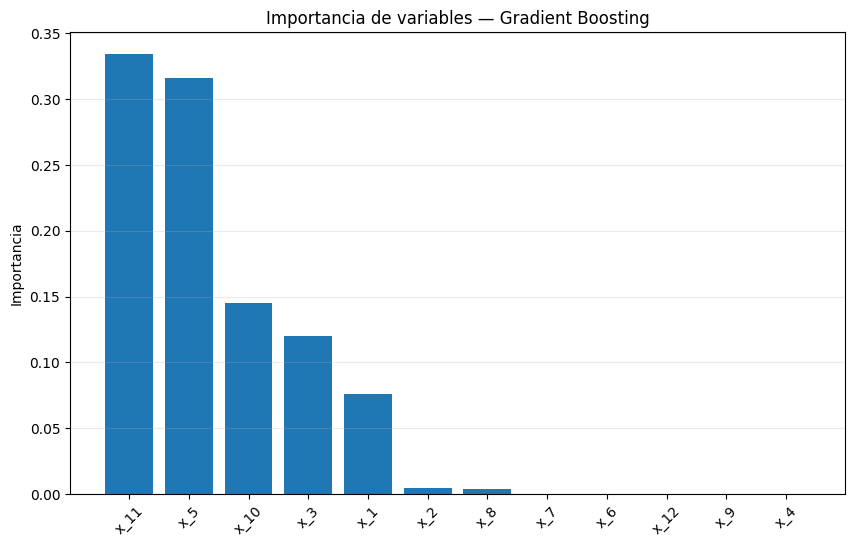

In [21]:
plt.figure(figsize=(10, 6))
plt.bar(
    gb_importance["Variable"],
    gb_importance["Importancia"],
)
plt.ylabel("Importancia")
plt.title("Importancia de variables — Gradient Boosting")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.show()


# Parte IV. Comparación final

## 16. Árbol, Random Forest y Gradient Boosting

In [22]:
comparison = pd.DataFrame([
    {
        "Modelo": "Árbol individual",
        **regression_metrics(y_test, tree_test_pred),
    },
    {
        "Modelo": "Random Forest",
        **regression_metrics(y_test, rf_test_pred),
    },
    {
        "Modelo": "Gradient Boosting",
        **regression_metrics(y_test, gb_test_pred),
    },
])

comparison.sort_values("RMSE")


,Modelo,MAE,RMSE,R²
2,Gradient Boosting,31.1758,41.4650,0.9447
1,Random Forest,59.7315,77.8717,0.8049
0,Árbol individual,84.7820,105.6538,0.6408


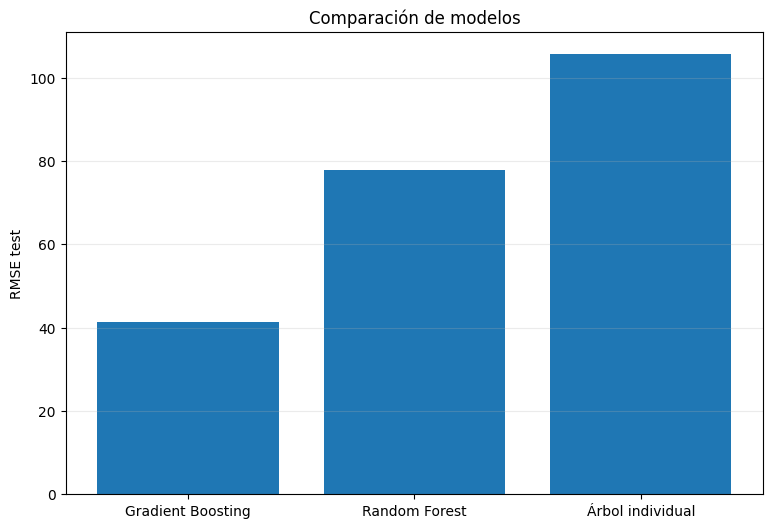

In [23]:
ordered_comparison = comparison.sort_values("RMSE")

plt.figure(figsize=(9, 6))
plt.bar(
    ordered_comparison["Modelo"],
    ordered_comparison["RMSE"],
)
plt.ylabel("RMSE test")
plt.title("Comparación de modelos")
plt.grid(axis="y", alpha=0.25)
plt.show()


## 17. Diferencias conceptuales

### Random Forest

- árboles independientes;
- entrenamiento paralelizable;
- principalmente reduce varianza;
- robusto y relativamente fácil de ajustar;
- buen modelo base para datos tabulares.

### Gradient Boosting

- árboles secuenciales;
- menos paralelizable;
- corrige errores paso a paso;
- puede reducir sesgo;
- más sensible a hiperparámetros y overfitting.

## 18. Errores frecuentes

1. Pensar que Random Forest y Gradient Boosting funcionan igual.
2. Usar pocos árboles en Random Forest y concluir que es inestable.
3. Usar `learning_rate` alto con demasiados árboles.
4. Seleccionar hiperparámetros con test.
5. Interpretar importancia como causalidad.
6. Ignorar variables correlacionadas en permutation importance.
7. Comparar modelos sin usar el mismo split.
8. No revisar la brecha train-test.
9. Asumir que boosting siempre supera a Random Forest.
10. Ignorar tiempo de entrenamiento y costo de mantenimiento.

## 19. Experimentos sugeridos

1. Cambia `n_estimators` en Random Forest.
2. Compara `max_features="sqrt"` y `max_features=1.0`.
3. Prueba distintos valores de `min_samples_leaf`.
4. Compara OOB y desempeño en test.
5. Cambia `learning_rate` y `n_estimators` conjuntamente.
6. Prueba árboles de mayor profundidad en boosting.
7. Introduce más ruido.
8. Agrega variables irrelevantes.
9. Compara tiempos de entrenamiento y predicción.
10. Usa validación cruzada para seleccionar hiperparámetros.

## 20. Resumen

En este notebook:

- utilizamos un árbol individual como baseline;
- construimos Random Forest mediante bagging;
- estudiamos bootstrap, OOB y `max_features`;
- analizamos el efecto del número de árboles;
- revisamos importancia por impureza y permutación;
- construimos Gradient Boosting secuencialmente;
- estudiamos `learning_rate`, profundidad y número de estimadores;
- analizamos la evolución del error;
- comparamos desempeño y características prácticas.

Random Forest prioriza robustez y reducción de varianza; Gradient Boosting prioriza corrección secuencial y capacidad predictiva.